<a href="https://www.kaggle.com/code/sidharthmurali1/optiver-closing-cross-microstructure-alpha?scriptVersionId=346260681" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Loaded 5,237,760 rows across 481 days and 200 stocks
After removing overlap: 952,320 rows, ~10 independent windows/stock/day
Train: 386 days | Test: 95 days
OUT-OF-SAMPLE STRATEGY PERFORMANCE (test set only)
Test days               : 95
Information Coefficient : -0.1030
Turnover                : 72.28% of ticks traded
Annualized Sharpe        : -103.539
95% CI on Sharpe         : [-118.60, -88.47]
Max Drawdown             : -26.93%
Mean daily return        : -33.29 bps


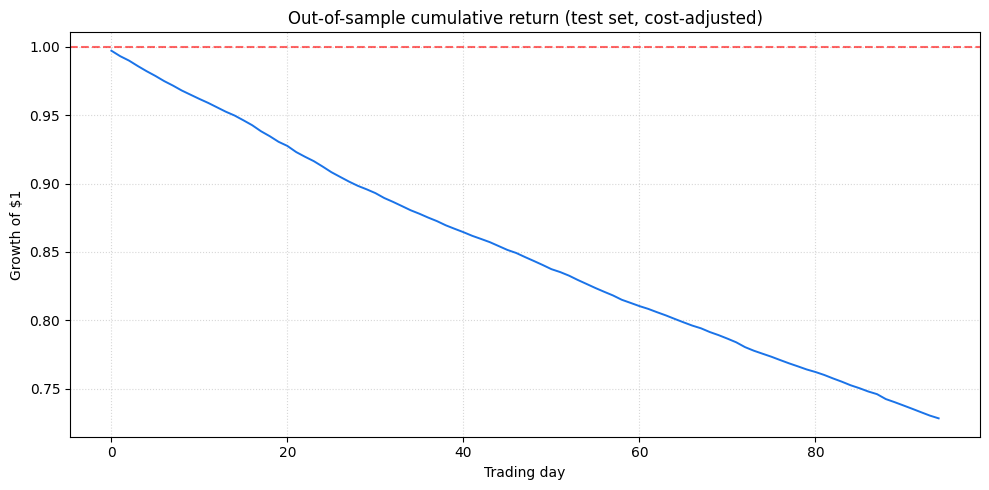

Mean daily GROSS (pre-cost) return : 7.09 bps
Mean daily COST drag               : 40.38 bps
Gross (no-cost) Sharpe              : 52.590
FINAL OUT-OF-SAMPLE RESULT — threshold = 0.7
Test days                    : 95
Information Coefficient      : -0.1030
Trades taken                 : 55,362  (29.1% of ticks)
Mean daily GROSS return      : 4.75 bps
Mean daily COST drag         : 16.18 bps
Mean daily NET return        : -11.43 bps
Annualized Sharpe (net)      : -69.32
95% CI on Sharpe             : [-79.69, -58.96]
Max Drawdown                 : -10.21%


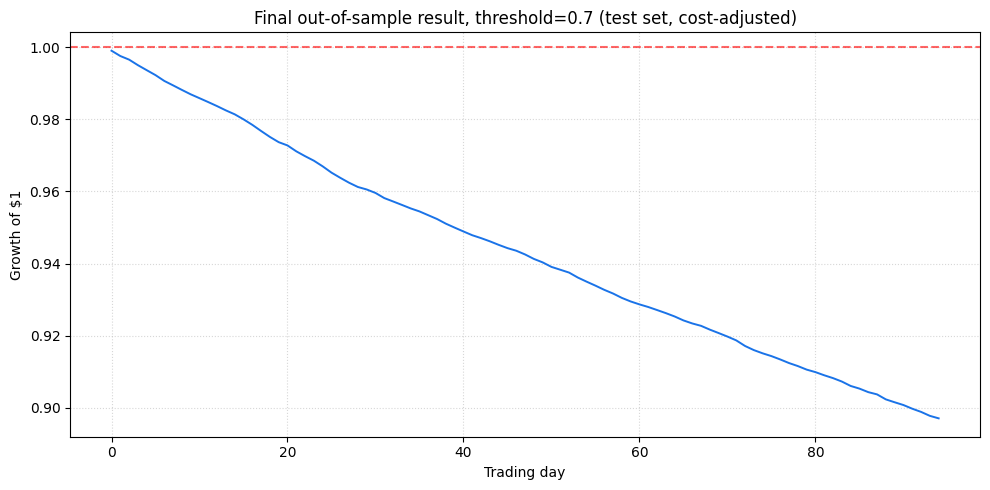

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load Data — FIX #3: no artificial row cap
# ------------------------------------------------------------
# Load the full file. If Kaggle runtime/memory is a concern, you can
# still cap this while testing your code (e.g. nrows=1_000_000), but
# your FINAL reported numbers should come from a run without a cap,
# or at minimum enough rows to cover a few hundred date_ids.
df = pd.read_csv('/kaggle/input/competitions/optiver-trading-at-the-close/train.csv')

df = df.dropna(subset=["bid_price", "ask_price", "bid_size", "ask_size", "target"])

print(f"Loaded {len(df):,} rows across {df['date_id'].nunique()} days and {df['stock_id'].nunique()} stocks")

# ------------------------------------------------------------
# 2. Microstructure features (unchanged, this part was fine)
# ------------------------------------------------------------
df["wap"] = (
    (df["bid_price"] * df["ask_size"]) + (df["ask_price"] * df["bid_size"])
) / (df["bid_size"] + df["ask_size"])

df["imbalance"] = (
    (df["bid_size"] - df["ask_size"]) / (df["bid_size"] + df["ask_size"])
)

# ------------------------------------------------------------
# 3. FIX: non-overlapping sampling
# ------------------------------------------------------------
# target = 60s forward return, ticks arrive every 10s, so only keep
# rows at 60-second spacing (0, 60, 120, ...) to avoid any two rows
# sharing the same underlying price move.
NON_OVERLAP_TICKS = list(range(0, 550, 60))
df = df[df["seconds_in_bucket"].isin(NON_OVERLAP_TICKS)].copy()

print(f"After removing overlap: {len(df):,} rows, "
      f"~{len(NON_OVERLAP_TICKS)} independent windows/stock/day")

# ------------------------------------------------------------
# 4. Train / test split — real out-of-sample evaluation
# ------------------------------------------------------------
# Split by date_id, not randomly, so nothing from the future
# leaks into the training side.
cutoff = df["date_id"].quantile(0.8)
train_df = df[df["date_id"] <= cutoff].copy()
test_df  = df[df["date_id"] >  cutoff].copy()

print(f"Train: {train_df['date_id'].nunique()} days | "
      f"Test: {test_df['date_id'].nunique()} days")

# ------------------------------------------------------------
# 5. Signal — threshold chosen on TRAIN only (no peeking at test)
# ------------------------------------------------------------
THRESHOLD = 0.25  # keeping your original threshold for now;
                   # could be tuned on train_df later if you want

def add_signal(d):
    d = d.copy()
    d["signal"] = np.select(
        [d["imbalance"] > THRESHOLD, d["imbalance"] < -THRESHOLD],
        [-1, 1],
        default=0
    )
    return d

train_df = add_signal(train_df)
test_df  = add_signal(test_df)

# ------------------------------------------------------------
# 6. Transaction costs — FIX: use the real spread in the data
# ------------------------------------------------------------
# Estimate one-way trading cost in bps from the actual bid-ask spread.
# This is a simplifying assumption (real cost also depends on order
# size vs. available depth), but it's a genuine, data-driven estimate
# instead of assuming zero cost.
def add_costs(d):
    d = d.copy()
    d["spread_bps"] = (d["ask_price"] - d["bid_price"]) / d["wap"] * 10000
    d["raw_return_bps"] = d["signal"] * d["target"]
    d["cost_bps"] = np.where(d["signal"] != 0, d["spread_bps"], 0.0)
    d["net_return_bps"] = d["raw_return_bps"] - d["cost_bps"]
    d["strategy_return"] = d["net_return_bps"] / 10000.0  # back to decimal
    return d

test_df = add_costs(test_df)

# ------------------------------------------------------------
# 7. Metrics — computed ONLY on the held-out test set
# ------------------------------------------------------------
ic = test_df["imbalance"].corr(test_df["target"])
active_trades = (test_df["signal"] != 0).sum()
turnover = active_trades / len(test_df)

# FIX: aggregate cross-sectionally first (one return per moment,
# not one per stock treated as an independent period)
portfolio_returns = test_df.groupby(['date_id', 'seconds_in_bucket'])['strategy_return'].mean()

# then collapse to ONE return per day (sum of that day's non-overlapping windows)
daily_returns = portfolio_returns.groupby('date_id').sum()

mean_d, std_d, n_days = daily_returns.mean(), daily_returns.std(), len(daily_returns)
sharpe = (mean_d / std_d) * np.sqrt(252) if std_d != 0 else 0

# Max drawdown, computed on the same clean daily series
cum = (1 + daily_returns).cumprod()
running_max = cum.cummax()
drawdown = (cum - running_max) / running_max
max_dd = drawdown.min()

# Lo (2002) standard error on the annualized Sharpe
daily_sharpe = mean_d / std_d if std_d != 0 else 0
se_annualized = np.sqrt((1 + 0.5 * daily_sharpe**2) / n_days) * np.sqrt(252)
ci_low, ci_high = sharpe - 1.96*se_annualized, sharpe + 1.96*se_annualized

print("="*50)
print("OUT-OF-SAMPLE STRATEGY PERFORMANCE (test set only)")
print("="*50)
print(f"Test days               : {n_days}")
print(f"Information Coefficient : {ic:.4f}")
print(f"Turnover                : {turnover*100:.2f}% of ticks traded")
print(f"Annualized Sharpe        : {sharpe:.3f}")
print(f"95% CI on Sharpe         : [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Max Drawdown             : {max_dd*100:.2f}%")
print(f"Mean daily return        : {mean_d*10000:.2f} bps")
print("="*50)

plt.figure(figsize=(10, 5), dpi=100)
plt.plot(cum.values, color="#1a73e8", linewidth=1.4)
plt.axhline(1, color="red", linestyle="--", alpha=0.6)
plt.title("Out-of-sample cumulative return (test set, cost-adjusted)")
plt.xlabel("Trading day")
plt.ylabel("Growth of $1")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

gross = test_df.groupby(['date_id','seconds_in_bucket'])['raw_return_bps'].mean()
cost  = test_df.groupby(['date_id','seconds_in_bucket'])['cost_bps'].mean()

daily_gross = gross.groupby('date_id').sum() / 10000
daily_cost  = cost.groupby('date_id').sum() / 10000

print(f"Mean daily GROSS (pre-cost) return : {daily_gross.mean()*10000:.2f} bps")
print(f"Mean daily COST drag               : {daily_cost.mean()*10000:.2f} bps")
gross_sharpe = (daily_gross.mean() / daily_gross.std()) * np.sqrt(252)
print(f"Gross (no-cost) Sharpe              : {gross_sharpe:.3f}")

# tune threshold on TRAIN only, then check the winning threshold's
# cost-adjusted performance on the untouched TEST set

# ------------------------------------------------------------
# FINAL OUT-OF-SAMPLE CHECK — threshold=0.70, chosen from the
# train-set sweep. Run this ONCE against the test set and stop,
# no further threshold searching after seeing this result.
# ------------------------------------------------------------

FINAL_THRESHOLD = 0.70

final_test = test_df.copy()
final_test["signal"] = np.select(
    [final_test["imbalance"] > FINAL_THRESHOLD, final_test["imbalance"] < -FINAL_THRESHOLD],
    [-1, 1], default=0
)
final_test["spread_bps"] = (final_test["ask_price"] - final_test["bid_price"]) / final_test["wap"] * 10000
final_test["raw_return_bps"] = final_test["signal"] * final_test["target"]
final_test["cost_bps"] = np.where(final_test["signal"] != 0, final_test["spread_bps"], 0.0)
final_test["net_return_bps"] = final_test["raw_return_bps"] - final_test["cost_bps"]
final_test["strategy_return"] = final_test["net_return_bps"] / 10000.0

# IC — same as before, this is threshold-independent (raw imbalance vs target)
ic = final_test["imbalance"].corr(final_test["target"])

# gross vs cost breakdown, same as we did before, for the full story
gross_port = final_test.groupby(['date_id','seconds_in_bucket'])['raw_return_bps'].mean()
cost_port  = final_test.groupby(['date_id','seconds_in_bucket'])['cost_bps'].mean()
daily_gross = gross_port.groupby('date_id').sum() / 10000
daily_cost  = cost_port.groupby('date_id').sum() / 10000

# net, cross-sectionally aggregated then collapsed to one return per day
net_port = final_test.groupby(['date_id','seconds_in_bucket'])['strategy_return'].mean()
daily_net = net_port.groupby('date_id').sum()

n_days = len(daily_net)
mean_d, std_d = daily_net.mean(), daily_net.std()
sharpe = (mean_d / std_d) * np.sqrt(252) if std_d != 0 else 0

daily_sharpe = mean_d / std_d if std_d != 0 else 0
se_annualized = np.sqrt((1 + 0.5*daily_sharpe**2) / n_days) * np.sqrt(252)
ci_low, ci_high = sharpe - 1.96*se_annualized, sharpe + 1.96*se_annualized

cum = (1 + daily_net).cumprod()
max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

turnover = (final_test["signal"] != 0).mean()
n_trades = (final_test["signal"] != 0).sum()

print("="*55)
print(f"FINAL OUT-OF-SAMPLE RESULT — threshold = {FINAL_THRESHOLD}")
print("="*55)
print(f"Test days                    : {n_days}")
print(f"Information Coefficient      : {ic:.4f}")
print(f"Trades taken                 : {n_trades:,}  ({turnover*100:.1f}% of ticks)")
print(f"Mean daily GROSS return      : {daily_gross.mean()*10000:.2f} bps")
print(f"Mean daily COST drag         : {daily_cost.mean()*10000:.2f} bps")
print(f"Mean daily NET return        : {mean_d*10000:.2f} bps")
print(f"Annualized Sharpe (net)      : {sharpe:.2f}")
print(f"95% CI on Sharpe             : [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Max Drawdown                 : {max_dd*100:.2f}%")
print("="*55)

plt.figure(figsize=(10,5), dpi=100)
plt.plot(cum.values, color="#1a73e8", linewidth=1.4)
plt.axhline(1, color="red", linestyle="--", alpha=0.6)
plt.title(f"Final out-of-sample result, threshold={FINAL_THRESHOLD} (test set, cost-adjusted)")
plt.xlabel("Trading day")
plt.ylabel("Growth of $1")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()